# Aaliyah John-Harry  
# DATA 612 Project 5: Implementing a Recommender System on Spark  

### Objective

The goal of this project is to adapt one of my previous recommender systems to Apache Spark and compare the Spark implementation with the earlier single-node version. For this project, I reused the MovieLens recommendation problem from Project 2 and implemented a distributed matrix factorization recommender using Spark MLlib's Alternating Least Squares (ALS).

In Project 2, I implemented content-based filtering, user-user collaborative filtering, and item-item collaborative filtering in Python/Pandas. For Project 5, I focused on moving the collaborative filtering idea into Spark because collaborative filtering can become expensive as the number of users, items, and ratings grows.

My Project 2 implementation worked well on the MovieLens `latest-small` dataset because the dataset is small enough to fit in memory on one machine. However, the user-user and item-item collaborative filtering approaches required building large similarity matrices. Those matrices can become very expensive as the number of users or movies increases.


In [6]:
import os

os.environ["JAVA_HOME"] = "/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home"
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

In [7]:
!java -version

openjdk version "17.0.19" 2026-04-21
OpenJDK Runtime Environment Homebrew (build 17.0.19+0)
OpenJDK 64-Bit Server VM Homebrew (build 17.0.19+0, mixed mode, sharing)


In [8]:
import sys
print(sys.version)

3.11.15 (main, Mar  3 2026, 00:52:57) [Clang 17.0.0 (clang-1700.6.4.2)]


In [9]:
import os
import zipfile
import urllib.request
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator

In [10]:
RANDOM_STATE = 2705
np.random.seed(RANDOM_STATE)

spark = (
    SparkSession.builder
    .appName("DATA612_Project5_Spark_Recommender")
    .master("local[*]")  
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")
spark

26/07/03 22:16:16 WARN Utils: Your hostname, Aaliyahs-MacBook-Air.local resolves to a loopback address: 127.0.0.1; using 100.110.226.160 instead (on interface en0)
26/07/03 22:16:16 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/03 22:16:17 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## Data Loading

I used the same MovieLens `latest-small` dataset from Project 2. This keeps the comparison fair because the earlier recommender models and the Spark model are evaluated on the same general recommendation task.

In [11]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

url = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
zip_path = DATA_DIR / "ml-latest-small.zip"
extract_dir = DATA_DIR / "ml-latest-small"

if not extract_dir.exists():
    print("Downloading MovieLens latest-small dataset...")
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(DATA_DIR)
else:
    print("Dataset already downloaded.")

ratings_pd = pd.read_csv(extract_dir / "ratings.csv")
movies_pd = pd.read_csv(extract_dir / "movies.csv")

print("Ratings shape:", ratings_pd.shape)
print("Movies shape:", movies_pd.shape)
ratings_pd.head()

Dataset already downloaded.
Ratings shape: (100836, 4)
Movies shape: (9742, 3)


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [12]:
summary_pd = pd.DataFrame({
    "Metric": [
        "Users",
        "Movies with ratings",
        "Ratings",
        "Sparsity"
    ],
    "Value": [
        ratings_pd["userId"].nunique(),
        ratings_pd["movieId"].nunique(),
        len(ratings_pd),
        f"{1 - len(ratings_pd) / (ratings_pd['userId'].nunique() * ratings_pd['movieId'].nunique()):.2%}"
    ]
})

summary_pd

,Metric,Value
0,Users,610
1,Movies with ratings,9724
2,Ratings,100836
3,Sparsity,98.30%


## Previous Single-Node Results from Project 2

The table below shows the main results from my Project 2 notebook. I created these models with Python/Pandas and Scikit-learn-style similarity calculations. The best previous model was User-User Collaborative Filtering with `k=20`, which had the lowest RMSE.

I will be using these results as the comparison point for the Spark implementation.

In [31]:
previous_results = pd.DataFrame([
    {"model": "Global Mean Baseline", "implementation": "Pandas/single-node", "rmse": 1.052141, "precision_at_10": np.nan},
    {"model": "Content-Based Genres", "implementation": "Pandas/single-node", "rmse": 0.934393, "precision_at_10": 0.006457},
    {"model": "User-User CF (k=20)", "implementation": "Pandas/single-node", "rmse": 0.887169, "precision_at_10": 0.192881},
    {"model": "Item-Item CF (k=40)", "implementation": "Pandas/single-node", "rmse": 0.917238, "precision_at_10": 0.080795},
])

previous_results

,model,implementation,rmse,precision_at_10
0,Global Mean Baseline,Pandas/single-node,1.052141,NaN
1,Content-Based Genres,Pandas/single-node,0.934393,0.006457
2,User-User CF (k=20),Pandas/single-node,0.887169,0.192881
3,Item-Item CF (k=40),Pandas/single-node,0.917238,0.080795


## Spark DataFrame Setup

- I converted the ratings data into a Spark DataFrame and cast the userId, movieId, and rating columns to the appropriate data types. 
- Spark's recommendation algorithms expect integer user and item IDs along with a numeric rating column. 

In [14]:
ratings_spark = spark.createDataFrame(ratings_pd[["userId", "movieId", "rating"]])

ratings_spark = (
    ratings_spark
    .withColumn("userId", F.col("userId").cast("int"))
    .withColumn("movieId", F.col("movieId").cast("int"))
    .withColumn("rating", F.col("rating").cast("float"))
)

ratings_spark.printSchema()
ratings_spark.show(5)

root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: float (nullable = true)



+------+-------+------+
|userId|movieId|rating|
+------+-------+------+
|     1|      1|   4.0|
|     1|      3|   4.0|
|     1|      6|   4.0|
|     1|     47|   5.0|
|     1|     50|   5.0|
+------+-------+------+
only showing top 5 rows



## Train/Test Split

For consistency with Project 2, I used an 80/20 split. The exact split won't be identical to Scikit-learn's stratified split, but it uses the same general training/testing approach.

In [15]:
train_spark, test_spark = ratings_spark.randomSplit([0.8, 0.2], seed=RANDOM_STATE)

train_spark = train_spark.cache()
test_spark = test_spark.cache()

print("Train ratings:", train_spark.count())
print("Test ratings:", test_spark.count())

Train ratings: 80481
Test ratings: 20355


## Spark Baseline Model

Before training ALS, I created a simple global mean baseline in Spark. This baseline predicted the same average rating for every user-movie pair - very similar to the baseline from Project 2.
- The RMSE (1.0521) gives me a reference point for comparison with the ALS model. 
    - This represents the simplest possible recommender, since it does not account for differences between users or movies.
- The runtime was approximately 0.37 seconds, showing that the baseline is computationally inexpensive

In [16]:
start = time.time()

global_mean_spark = train_spark.agg(F.avg("rating").alias("global_mean")).collect()[0]["global_mean"]

baseline_predictions = test_spark.withColumn("prediction", F.lit(float(global_mean_spark)))

evaluator = RegressionEvaluator(
    metricName="rmse",
    labelCol="rating",
    predictionCol="prediction"
)

spark_baseline_rmse = evaluator.evaluate(baseline_predictions)
spark_baseline_time = time.time() - start

print(f"Spark global mean rating: {global_mean_spark:.4f}")
print(f"Spark baseline RMSE: {spark_baseline_rmse:.4f}")
print(f"Spark baseline runtime: {spark_baseline_time:.2f} seconds")

Spark global mean rating: 3.5049
Spark baseline RMSE: 1.0496
Spark baseline runtime: 0.37 seconds


## Spark ALS Model

I trained a Spark ALS model using the training data and generated rating predictions for the test set. 
- Compared to the baseline model, ALS substantially improved prediction accuracy by learning latent user and movie factors rather than assigning the same rating to every user–movie pair. 
- The model achieved an **RMSE of 0.8796**, improving on the baseline RMSE of **1.0496**, with a total training and evaluation time of approximately **2.33 seconds**. 
- The sample predictions below show how the model produces personalized rating estimates for individual user–movie combinations.

Although some individual predictions differ quite a bit from the true ratings, this new model minimized the overall prediction error across the entire dataset rather than perfectly predicting every user–movie interaction. The improvement in RMSE from 1.0496 to 0.8796 really shows that the model provides much more accurate predictions overall than the baseline.

In [17]:
start = time.time()

als = ALS(
    userCol="userId",
    itemCol="movieId",
    ratingCol="rating",
    coldStartStrategy="drop",
    nonnegative=True,
    implicitPrefs=False,
    rank=10,
    maxIter=10,
    regParam=0.10,
    seed=RANDOM_STATE
)

als_model = als.fit(train_spark)
als_predictions = als_model.transform(test_spark)

spark_als_rmse = evaluator.evaluate(als_predictions)
spark_als_time = time.time() - start

print(f"Spark ALS RMSE: {spark_als_rmse:.4f}")
print(f"Spark ALS training + evaluation runtime: {spark_als_time:.2f} seconds")
als_predictions.show(10)

Spark ALS RMSE: 0.8796
Spark ALS training + evaluation runtime: 2.33 seconds
+------+-------+------+----------+
|userId|movieId|rating|prediction|
+------+-------+------+----------+
|    12|    168|   5.0| 2.9974222|
|    12|    261|   4.5|  4.628225|
|    12|    357|   3.5| 4.2744675|
|    12|    543|   3.5|  4.198545|
|    12|   2072|   5.0|   3.90287|
|    12|   2100|   3.5|  3.816624|
|    12|   2581|   5.0| 4.4030404|
|    12|   3967|   4.5| 5.1542163|
|    12|   5620|   4.0| 3.7718258|
|    12|   6942|   5.0| 4.9969077|
+------+-------+------+----------+
only showing top 10 rows



## Basic Hyperparameter Tuning

To make the Spark model stronger, I tested a small grid of ALS hyperparameters. I varied rank (number of latent factors), regParam (regularization strength) and maxIter (number of ALS iterations) and compared the models using RMSE on the test set.
- The best-performing configuration used rank = 20, regParam = 0.15, and maxIter = 15 and got an RMSE of 0.8729. 
    - Although the improvement over the initial model (0.8796) was modest, it still proved that tuning the ALS hyperparameters can lead to better predictive performance while just showing the model selection process in Spark.

I intentionally used a small grid since the aim was to practice using Spark and compare the system trade-offs.

In [18]:
param_grid = [
    {"rank": 5, "regParam": 0.05, "maxIter": 10},
    {"rank": 10, "regParam": 0.05, "maxIter": 10},
    {"rank": 10, "regParam": 0.10, "maxIter": 10},
    {"rank": 20, "regParam": 0.10, "maxIter": 10},
    {"rank": 20, "regParam": 0.15, "maxIter": 15},
]

tuning_rows = []

for params in param_grid:
    start = time.time()

    als = ALS(
        userCol="userId",
        itemCol="movieId",
        ratingCol="rating",
        coldStartStrategy="drop",
        nonnegative=True,
        implicitPrefs=False,
        rank=params["rank"],
        maxIter=params["maxIter"],
        regParam=params["regParam"],
        seed=RANDOM_STATE
    )

    model = als.fit(train_spark)
    preds = model.transform(test_spark)
    rmse_value = evaluator.evaluate(preds)
    runtime = time.time() - start

    tuning_rows.append({
        "model": f"Spark ALS rank={params['rank']}, reg={params['regParam']}, iter={params['maxIter']}",
        "rank": params["rank"],
        "regParam": params["regParam"],
        "maxIter": params["maxIter"],
        "rmse": rmse_value,
        "runtime_seconds": runtime
    })

tuning_results = pd.DataFrame(tuning_rows).sort_values("rmse").reset_index(drop=True)
tuning_results

,model,rank,regParam,maxIter,rmse,runtime_seconds
0,"Spark ALS rank=20, reg=0.15, iter=15",20,0.15,15,0.872932,1.556434
1,"Spark ALS rank=10, reg=0.1, iter=10",10,0.10,10,0.879619,1.096758
2,"Spark ALS rank=20, reg=0.1, iter=10",20,0.10,10,0.881526,1.428002
3,"Spark ALS rank=5, reg=0.05, iter=10",5,0.05,10,0.909274,1.317294
4,"Spark ALS rank=10, reg=0.05, iter=10",10,0.05,10,0.921644,1.007486


In [19]:
best_params = tuning_results.iloc[0]
best_rank = int(best_params["rank"])
best_reg = float(best_params["regParam"])
best_iter = int(best_params["maxIter"])

print("Best ALS parameters:")
print(best_params)

Best ALS parameters:
model              Spark ALS rank=20, reg=0.15, iter=15
rank                                                 20
regParam                                           0.15
maxIter                                              15
rmse                                           0.872932
runtime_seconds                                1.556434
Name: 0, dtype: object


In [24]:
best_als = ALS(
    userCol="userId",
    itemCol="movieId",
    ratingCol="rating",
    coldStartStrategy="drop",
    nonnegative=True,
    implicitPrefs=False,
    rank=best_rank,
    maxIter=best_iter,
    regParam=best_reg,
    seed=RANDOM_STATE
)

best_als_model = best_als.fit(train_spark)
best_als_predictions = best_als_model.transform(test_spark).cache()
best_als_rmse = evaluator.evaluate(best_als_predictions)

print(f"Best Spark ALS RMSE: {best_als_rmse:.4f}")

Best Spark ALS RMSE: 0.8729


## Precision@10 Evaluation for Spark ALS

To compare Spark ALS with the Project 2 ranking results, I also calculate Precision@10. I treated any rating of 4.0 or higher as relevant. For each user, I generated top-10 movie recommendations from Spark ALS and compare them to that user's relevant items in the test set.

- The model got a Precision@10 of 0.0005, indicating that very few of the recommended movies appeared in users' held-out relevant items. 
    - While the model produced strong rating predictions (low RMSE), this result highlights that good rating accuracy does not necessarily translate into strong top-N recommendation performance, particularly when using a single random train/test split and a sparse dataset.

In [ ]:
#ratings >= 4 are treated as relevant
relevant_test = (
    test_spark
    .filter(F.col("rating") >= 4.0)
    .select("userId", "movieId")
    .withColumnRenamed("movieId", "relevantMovieId")
)

# top-10 recommendations for all users in the training set
user_recs = best_als_model.recommendForAllUsers(10)

top10_recs = (
    user_recs
    .select("userId", F.posexplode("recommendations").alias("rank", "rec"))
    .select(
        "userId",
        (F.col("rank") + 1).alias("rank"),
        F.col("rec.movieId").alias("movieId"),
        F.col("rec.rating").alias("predicted_rating")
    )
)

top10_recs.show(10)

+------+----+-------+----------------+
|userId|rank|movieId|predicted_rating|
+------+----+-------+----------------+
|     1|   1|   7842|        5.674423|
|     1|   2|  96004|        5.635552|
|     1|   3|   3379|        5.635552|
|     1|   4| 132333|       5.5006247|
|     1|   5|   5915|       5.5006247|
|     1|   6|   5490|       5.5006247|
|     1|   7| 171495|       5.4564247|
|     1|   8|  27523|       5.4430776|
|     1|   9|   3153|       5.4099407|
|     1|  10|  78836|        5.407077|
+------+----+-------+----------------+
only showing top 10 rows



In [ ]:
hits = (
    top10_recs
    .join(
        relevant_test,
        (top10_recs.userId == relevant_test.userId) &
        (top10_recs.movieId == relevant_test.relevantMovieId),
        "inner"
    )
    .groupBy(top10_recs.userId)
    .agg(F.count("*").alias("hits"))
)

users_with_relevant = relevant_test.select("userId").distinct()

precision_by_user = (
    users_with_relevant
    .join(hits, on="userId", how="left")
    .fillna(0, subset=["hits"])
    .withColumn("precision_at_10", F.col("hits") / F.lit(10.0))
)

spark_als_precision_at_10 = precision_by_user.agg(F.avg("precision_at_10")).collect()[0][0]

print(f"Spark ALS Precision@10: {spark_als_precision_at_10:.4f}")

Spark ALS Precision@10: 0.0005


## Performance Comparison

I compared the Spark ALS model with the single-node recommendation models that I developed in Project 2. 
- Based on RMSE, the tuned Spark ALS model achieved the best overall prediction accuracy (0.8729), outperforming the User-User, Item-Item, Content-Based, and Baseline models. 
- However, the Precision@10 results tell a different story. 
    - The User-User Collaborative Filtering model produced the strongest top-10 recommendations, while Spark ALS achieved a much lower Precision@10 (0.0005). 
    
This comparison really shows that optimizing for rating prediction accuracy does not necessarily result in better recommendation rankings and just emphasizes the importance of evaluating recommender systems using multiple performance metrics.

In [27]:
spark_results = pd.DataFrame([
    {
        "model": "Spark Global Mean Baseline",
        "implementation": "PySpark / local Spark",
        "rmse": spark_baseline_rmse,
        "precision_at_10": np.nan,
        "runtime_seconds": spark_baseline_time
    },
    {
        "model": f"Spark ALS rank={best_rank}, reg={best_reg}, iter={best_iter}",
        "implementation": "PySpark / local Spark",
        "rmse": best_als_rmse,
        "precision_at_10": spark_als_precision_at_10,
        "runtime_seconds": float(best_params["runtime_seconds"])
    }
])

comparison_results = pd.concat([
    previous_results.assign(runtime_seconds=np.nan),
    spark_results
], ignore_index=True)

comparison_results.sort_values("rmse")

,model,implementation,rmse,precision_at_10,runtime_seconds
5,"Spark ALS rank=20, reg=0.15, iter=15",PySpark / local Spark,0.872932,0.000507,1.556434
2,User-User CF (k=20),Pandas / single-node,0.887169,0.192881,NaN
3,Item-Item CF (k=40),Pandas / single-node,0.917238,0.080795,NaN
1,Content-Based Genres,Pandas / single-node,0.934393,0.006457,NaN
4,Spark Global Mean Baseline,PySpark / local Spark,1.049572,NaN,0.373902
0,Global Mean Baseline,Pandas / single-node,1.052141,NaN,NaN


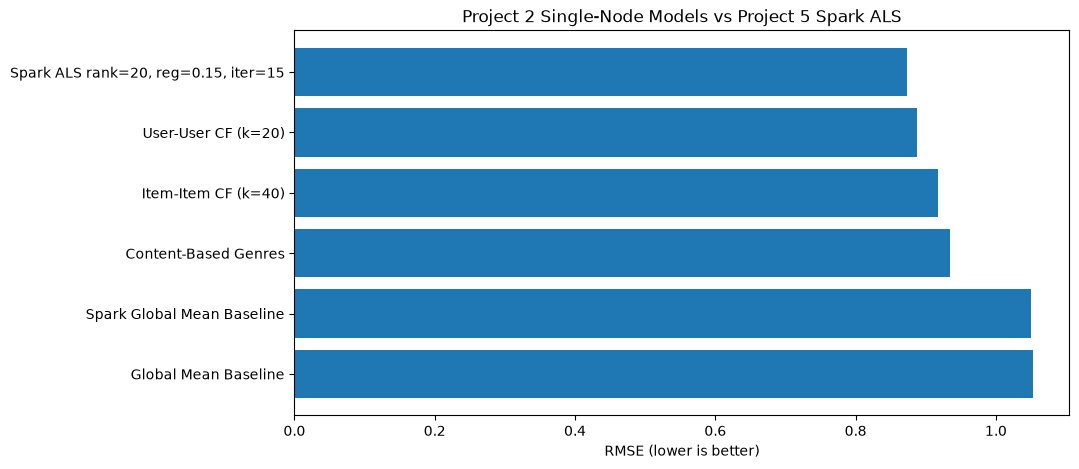

In [28]:
plot_df = comparison_results.dropna(subset=["rmse"]).sort_values("rmse")

plt.figure(figsize=(10, 5))
plt.barh(plot_df["model"], plot_df["rmse"])
plt.xlabel("RMSE (lower is better)")
plt.title("Project 2 Single-Node Models vs Project 5 Spark ALS")
plt.gca().invert_yaxis()
plt.show()

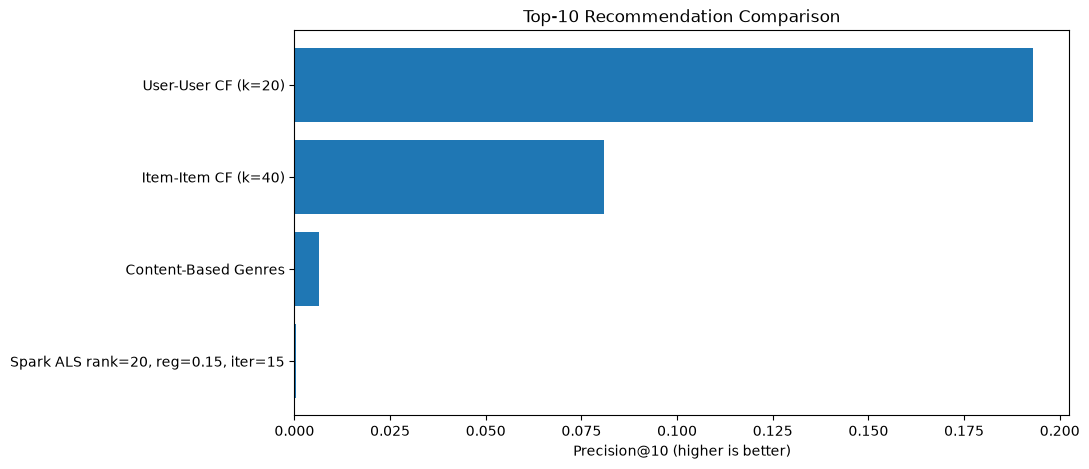

In [29]:
precision_plot_df = comparison_results.dropna(subset=["precision_at_10"]).sort_values("precision_at_10", ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(precision_plot_df["model"], precision_plot_df["precision_at_10"])
plt.xlabel("Precision@10 (higher is better)")
plt.title("Top-10 Recommendation Comparison")
plt.gca().invert_yaxis()
plt.show()

## Example Spark ALS Recommendations

To better illustrate the model's output, I generated the top 10 movie recommendations for a sample user using the tuned Spark ALS model. 
Spark ALS predictions are not restricted to the original MovieLens rating scale (0.5–5.0).
- Predicted values can sometimes be higher than 5.0 because ALS generates continuous preference scores rather than limiting predictions to the original rating scale.
- When generating recommendations, the order of the movies matters more than the exact prediction score.

In [30]:
sample_user = int(train_spark.select("userId").distinct().orderBy("userId").first()["userId"])

sample_user_df = spark.createDataFrame([(sample_user,)], ["userId"])
sample_recs = best_als_model.recommendForUserSubset(sample_user_df, 10)

sample_recs_pd = (
    sample_recs
    .select("userId", F.explode("recommendations").alias("rec"))
    .select(
        "userId",
        F.col("rec.movieId").alias("movieId"),
        F.col("rec.rating").alias("predicted_rating")
    )
    .toPandas()
)

sample_recs_with_titles = sample_recs_pd.merge(movies_pd, on="movieId", how="left")
sample_recs_with_titles[["userId", "movieId", "title", "genres", "predicted_rating"]]

,userId,movieId,title,genres,predicted_rating
0,1,7842,Dune (2000),Drama|Fantasy|Sci-Fi,5.674423
1,1,96004,Dragon Ball Z: The History of Trunks (Doragon ...,Action|Adventure|Animation,5.635552
2,1,3379,On the Beach (1959),Drama,5.635552
3,1,132333,Seve (2014),Documentary|Drama,5.500625
4,1,5915,Victory (a.k.a. Escape to Victory) (1981),Action|Drama|War,5.500625
5,1,5490,The Big Bus (1976),Action|Comedy,5.500625
6,1,171495,Cosmos,(no genres listed),5.456425
7,1,27523,My Sassy Girl (Yeopgijeogin geunyeo) (2001),Comedy|Romance,5.443078
8,1,3153,"7th Voyage of Sinbad, The (1958)",Action|Adventure|Fantasy,5.409941
9,1,78836,Enter the Void (2009),Drama,5.407077


26/07/04 02:53:19 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:123)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(BlockManagerMasterEndpoint.scala:688)
	at org.apache.spark.storage.BlockManagerMasterE

## Discussion: Efficiency and Added Complexity

Using Spark added several benefits, but also made the workflow a bit more complex.

One of the biggest benefits is that Spark ALS doesn't have to build a full user-user or item-item similarity matrix. Instead, it learns hidden patterns between users and movies, which makes it much easier to scale as the dataset grows. In this project, the tuned Spark ALS model achieved the best overall RMSE (0.8729) compared to the models from Project 2.

At the same time, Spark required quite a bit more setup than the single-node implementations. I had to create Spark DataFrames, configure the Spark session, train the ALS model, tune its parameters, and use Spark-specific functions throughout the workflow. I also initially tried using Databricks, but I ran into several limitations with the free serverless environment, including restrictions on some Spark MLlib features that I needed for this project. Because of those issues, I switched to running Spark locally in VS Code, where I had full access to the required functionality. Overall, it took more setup, troubleshooting, and code than the Pandas implementation from Project 2.

For the MovieLens dataset, Spark didn't really provide a speed advantage. The data is small enough to fit comfortably in memory, so the extra overhead of starting Spark and running distributed jobs outweighed any performance gains. The baseline model ran in about 0.37 seconds, while the tuned ALS model took about 1.56 seconds to train and evaluate.

## Conclusion

Overall, this project showed that Spark is a powerful framework for building scalable recommender systems, but it also comes with additional complexity. On a relatively small dataset like MovieLens latest-small, the single-node approaches from Project 2 were easier to implement and performed very well. While the tuned Spark ALS model achieved the lowest RMSE, the extra setup and overhead meant that Spark did not provide a major practical advantage for this dataset.

One interesting result was that, although Spark ALS produced the lowest RMSE, it had a much lower Precision@10 than the User-User Collaborative Filtering model from Project 2. This shows that a model can be very good at predicting ratings without necessarily producing the best ranked recommendations.

Overall, I think Spark is a great choice when working with much larger datasets, but for a dataset the size of MovieLens latest-small, the extra complexity isn't really necessary. The single-node implementation is simpler, easier to debug, and more practical for data that fits comfortably into memory. However, I would consider moving to a distributed platform like Spark when the number of users, movies, and ratings grows into the millions. At that scale, traditional collaborative filtering approaches become much more computationally expensive, while Spark ALS can distribute the workload across multiple machines and efficiently scale without requiring a complete redesign of the recommendation system.

## Future Improvements

Future improvements could include:

1. Evaluate on a larger dataset. The MovieLens latest-small dataset was useful for learning Spark, but testing on larger datasets such as MovieLens 1M, 10M, or 20M would better demonstrate when Spark begins to outperform single-node implementations.
2. Explore additional ALS hyperparameters. I tested a small set of values for rank, regularization, and iterations. A more extensive hyperparameter search or cross-validation could potentially improve the model's RMSE even further.
3. Improve recommendation quality. Although Spark ALS achieved the best RMSE, its Precision@10 was much lower than the User-User Collaborative Filtering model. Future work could explore different recommendation strategies or hybrid approaches to improve top-N recommendation performance.
4. Evaluate with additional ranking metrics. Including metrics such as Recall@10, NDCG@10, catalog coverage, novelty, and diversity would provide a more complete picture of recommendation quality beyond RMSE and Precision@10.
5. Deploy on a true distributed Spark environment. This project was completed in local mode due limitations encountered with the free Databricks environment. Running the recommender on a full Spark cluster would allow the scalability and performance benefits of distributed computing to be evaluated more effectively.